#### 숫자 손글씨 분류 모델
 - 데이터 : train.csv, t10k.csv
 - 정__보 : 흑백이미지, 28X28 사이즈
 - 확__인 : 이미지 데이터 레이블 체크

[1] 모듈 로딩 <hr>

In [1]:
## 모듈 로딩
import struct                      # 이미지 바이트 데이터로 변환 모듈
import os                          # 시스템 운영체제 제어 모듈
import pandas as pd                # 데이터 분석용 모듈
import matplotlib.pyplot as plt    # 데이터 시각화 모듈
import numpy as np                 # array 관련 모듈

[2] 데이터 준비 <hr>

In [2]:
## 데이터 불러오기
DATA_DIR   = '../Data/MNIST/'
TRAIN_FILE = DATA_DIR + 'train.csv'
TEST_FILE  = DATA_DIR + 't10k.csv'

In [3]:
# ## CSV 변환 메서드 --------------------------------
# DEBUG = True # 디버그 확인용

# def to_csv(name, maxdata) :
#     # (1) CSV 저장할 데이터 준비
#     # 레이블 파일과 이미지 파일 열기
#     lbl_f = open(DATA_DIR + name + "-labels-idx1-ubyte", "rb")     # 라벨 파일 바이너리모드 읽기
#     img_f = open(DATA_DIR + name + "-images-idx3-ubyte", "rb")     # 이미지 파일 바이너리드 읽기

#     # CSV 파일 생성 : 레이블(lbl_f), 이미지데이터(img_f)
#     csv_f = open(DATA_DIR + name + ".csv", "w", encoding="utf-8")  # CSV 파일 쓰기 모드 읽기

#     # 헤더 정보 읽기
#     _, lbl_count = struct.unpack(">II", lbl_f.read(8)) # 매직 코드 + 레이블 개수
#     _, img_count = struct.unpack(">II", img_f.read(8)) # 매직 코드 + 이미지 개수
#     rows, cols   = struct.unpack(">II", img_f.read(8)) # 행, 열 개수
#     pixcels = rows * cols                              # 한개 이미지의 픽셀수
#     if DEBUG :
#         print('lbl_count {}, img_count {}'.format(lbl_count, img_count))
#         print('rows {}, cols {}'.format(rows, cols))

#     # (2) 이미지 데이터를 읽고 CSV 파일로 저장
#     for idx in range(lbl_count) :
#         if idx > maxdata : break

#         # 숫자이미지 데이터가 의미하는 숫자값 읽기
#         label = struct.unpack("B", lbl_f.read(1))[0]  # "B" : unsigned byte(1바이트 정수) / [0] : struct.unpack 튜플 반환 첫 원소 꺼냄
#         if DEBUG : print(' label => {}'.format(label))

#         # 이미지 데이터 읽기
#         bdata = img_f.read(pixcels)   # bdata : 바이트 배열
#         sdata = list(map(str, bdata)) # sdata : 문자열 리스트로 변환
#         if DEBUG : print('sdata => {}'.format(sdata))

#         # CSV 파일에 쓰기
#         csv_f.write(str(label)+",")          # 라벨(정답숫자) + csv 식별(',')
#         csv_f.write(','.join(sdata) + "\n")  # row = label, 픽셀1, 픽셀2 ... 픽셀 784 -> 문자열 변환

#     csv_f.close()
#     lbl_f.close()
#     img_f.close()

In [4]:
## 학습용/훈련용 데이터 변환
## def to_csv(name, maxdata) :
# to_csv("train", 60000)   # train : 60000장 -> train.csv
# to_csv("t10k", 10000)    # test  : 10000장 -> t10k.csv

In [5]:
## 데이터 파일 불러오기
TRAIN_FILE = '../Data/MNIST/train.csv'
TEST_FILE = '../Data/MNIST/t10k.csv'

In [6]:
## 데이터 준비 CSV ==> DataFrame 형식으로 로딩
imgDF = pd.read_csv(TEST_FILE, header=None)
display(imgDF.head(3))
imgDF.info()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 59.9 MB


In [7]:
## 이미지 개수(행 수 ) 확인
with open("../Data/MNIST/train.csv", "r", encoding="utf-8") as f :
    line_count = sum(1 for _ in f) # 1 for _ in f -> 파일을 줄 단위 반복해서 줄마다 1 생성 후 모든 1을 더함 = 줄 수

print("train.csv 행 개수 =", line_count)

## 이미지 개수 (행 수 ) 확인
with open("../Data/MNIST/train.csv", "r", encoding="utf-8") as f :
    lines = f.readlines()
print("train.csv 행 개수 = ", len(lines))


train.csv 행 개수 = 60000
train.csv 행 개수 =  60000


In [8]:
## 데이터 정보 확인
## - entry -> entries 행
print(f'기본정보 \n{imgDF.shape}, {imgDF.ndim}D')

기본정보 
(10000, 785), 2D


[3] 데이터 추출 <hr>

In [9]:
## 행/가로줄 데이터 추출 => 라벨/타겟과 픽셀값
## 문법 : 변수명.iloc[행인덱스]
rowSR = imgDF.iloc[0]
rowSR

0      7
1      0
2      0
3      0
4      0
      ..
780    0
781    0
782    0
783    0
784    0
Name: 0, Length: 785, dtype: int64

In [10]:
## Label과 이미지 픽셀 데이터 분리
label = rowSR[0]
print(f'label => { label }')

label => 7


In [11]:
## rowSR의 1번 원소부터 끝까지 데이터 추출 => ndarray 타입!!
pixcels = rowSR[1:].values

print(f'pixcels => { type(pixcels)}, {pixcels.shape}, {pixcels.ndim}D')

pixcels => <class 'numpy.ndarray'>, (784,), 1D


In [12]:
## 이미지 픽셀 1D 데이터 => 2D 데이터 변환
pixcel2D = pixcels.reshape(28, 28)
print(f'pixcel2D => { type(pixcel2D)}, {pixcel2D.shape}, {pixcel2D.ndim}D')

pixcel2D => <class 'numpy.ndarray'>, (28, 28), 2D


[4] 픽셀데이터 ==> 이미지로 시각화

Text(0.5, 1.0, '[Label - 7]')

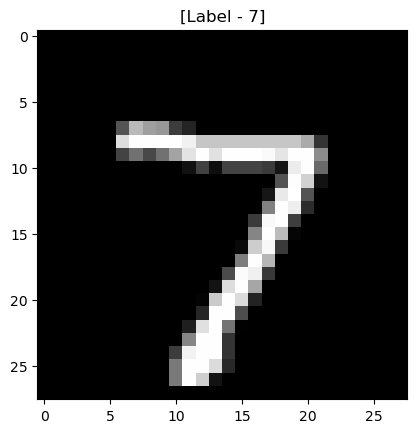

In [13]:
## 이미지 시각화
plt.imshow(pixcel2D, cmap='gray')
plt.title(f'[Label - {label}]')

In [14]:
## 랜덤으로 10개 데이터 추출해서 시각화
IDXs = imgDF[0].sample(10, random_state=10).index

print(f'IDXs => {IDXs}')

IDXs => Index([937, 9355, 2293, 192, 8675, 53, 9596, 265, 984, 9793], dtype='int64')


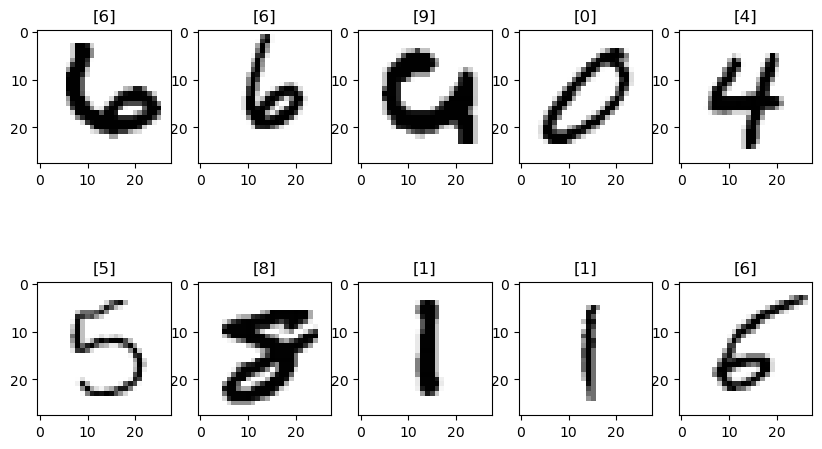

In [15]:
## 여러개 그래프 시각화 : plt.subplots(행, 열)
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for ax, idx in zip(axes, IDXs) :
    rowSR = imgDF.iloc[idx]
    label = rowSR[0]
    datas = rowSR[1:].values.reshape(28,28)
    ax.imshow(datas, cmap='gray_r')
    ax.set_title(f'[{label}]')
plt.show()

[5] KNN 모델 <hr>

In [16]:
## 모듈 로딩
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
## 파일 경로
DATA_DIR = '../Data/MNIST/'
TRAIN_FILE = DATA_DIR + "train.csv"  # (label, x1, x2, ... x784)
TEST_FILE  = DATA_DIR + "t10k.csv"   # (label, x1, x2, ... x784)

## KNN 옵션
USE_PCA = True                       # PCA 사용(주성분분석)
N_COMP  = 50                         # PCA 차원 수(50 ~ 100) 
KMAX    = 31                         # 한 번에 구할 최대 이웃 수
KS      = list(range(1, KMAX+1, 2))  # 탐색할 k 후보(홀수)       

In [18]:
## 라벨명 추출
labelSR = imgDF[0].unique()
labelSR = np.sort(labelSR.astype(int))
print(labelSR)

[0 1 2 3 4 5 6 7 8 9]


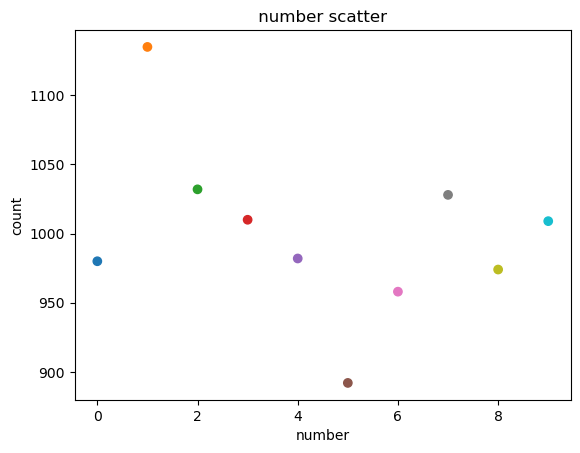

In [19]:
## 라벨들의 관계 : 산점도
# colors = imgDF.replace({0:"brown", 1:"orange", 2:"gold", 3:"olive", 4:"green", 5:"aqua", 6:"steelblue", 7:"slateblue", 8:"indigo", 9:"deeppink"})

## 라벨별 개수 집계
label_counts = imgDF[0].value_counts().sort_index()

## 산점도
plt.scatter( label_counts.index, label_counts.values,
            c=label_counts.index, cmap="tab10")
plt.xlabel('number')
plt.ylabel('count')
plt.title(" number scatter ")
plt.show()

In [20]:
## 타겟(label), 피쳐(data) 분리
## train 데이터
imgDF = pd.read_csv(TRAIN_FILE, header=None, dtype="int", low_memory=False)
dataDF = imgDF.iloc[:, 1:]  # (60000, 784)
labelSR = imgDF.iloc[:, 0]  # (60000,)

## test 데이터
testDF = pd.read_csv(TEST_FILE, header=None, dtype='int', low_memory=False)
X_test = testDF.iloc[:, 1:].to_numpy()
y_test = testDF.iloc[:, 0].to_numpy()

## numpy 변환
X_train = dataDF.to_numpy()
y_train = labelSR.to_numpy()

print(f'dataDF  : {dataDF.shape}, {dataDF.ndim}D')
print(f'labelSR : {labelSR.shape}, {labelSR.ndim}D')

print(f'TRAIN   : {X_train.shape}, {y_train.shape}')
print(f'TEST    : {X_test.shape}, {y_test.shape}')

dataDF  : (60000, 784), 2D
labelSR : (60000,), 1D
TRAIN   : (60000, 784), (60000,)
TEST    : (10000, 784), (10000,)


In [21]:
## 스케일링 및 PCA
## 0 ~ 255 -> 0 ~ 1, float 변환
X_trian_s = (X_train / 255.0).astype("float")
X_test_s  = (X_test / 255.0).astype("float")

## PCA 
if USE_PCA :
    pca = PCA(n_components=N_COMP, random_state=42)
    X_train_f = pca.fit_transform(X_trian_s)
    X_test_f  = pca.transform(X_test_s)

else : 
    X_train_f, x_test_f = X_trian_s, X_test_s

print("features : ", X_train_f.shape, X_test_f.shape)

features :  (60000, 50) (10000, 50)


In [22]:
## 최적 K 탐색(K 재사용)
KMAX = min(KMAX, len(X_train_f))

nbrs = NearestNeighbors(n_neighbors=KMAX, n_jobs=-1)
nbrs.fit(X_train_f)

train_idx = nbrs.kneighbors(X_train_f, return_distance=False) 
test_idx  = nbrs.kneighbors(X_test_f, return_distance=False)

## 각 샘플 이웃 라벨
y_train_neighbors = y_train[train_idx]
y_test_neighbors  = y_train[test_idx]

def majority_vote(neigh_labels, k, num_classes=10) :
    # 행마다 앞 k개 이웃 빈도 argmax
    return np.apply_along_axis(
        lambda row : np.bincount(row[:k], minlength=num_classes).argmax(),
        axis = 1, arr=neigh_labels)

## k별 성능
scoreDF = pd.DataFrame(columns=["k", "train", "test", "gab"])
for k in KS :
    ytr_pred = majority_vote(y_train_neighbors, k)
    yte_pred = majority_vote(y_test_neighbors, k)
    tr = (ytr_pred == y_train).mean()
    te = (yte_pred == y_test ).mean()
    gap = abs(tr-te)
    scoreDF.loc[len(scoreDF)] = [k, tr, te, gap]
    print(f"k={k:2d}  train={tr:.4f}  test={te:.4f}  gap={gap:.5f}")

scoreDF  = scoreDF.sort_values("k").reset_index(drop=True)
best_row = scoreDF.iloc[scoreDF["test"].idxmax()]
best_k   = int(best_row["k"])
print(f'[BESET] k={best_k} train={best_row.train:.4f} test={best_row.test:.4f}')

k= 1  train=1.0000  test=0.9734  gap=0.02660
k= 3  train=0.9895  test=0.9752  gap=0.01427
k= 5  train=0.9859  test=0.9748  gap=0.01110
k= 7  train=0.9836  test=0.9751  gap=0.00850
k= 9  train=0.9817  test=0.9752  gap=0.00652
k=11  train=0.9798  test=0.9743  gap=0.00555
k=13  train=0.9784  test=0.9730  gap=0.00535
k=15  train=0.9767  test=0.9717  gap=0.00498
k=17  train=0.9753  test=0.9719  gap=0.00338
k=19  train=0.9740  test=0.9707  gap=0.00330
k=21  train=0.9730  test=0.9705  gap=0.00248
k=23  train=0.9720  test=0.9687  gap=0.00327
k=25  train=0.9709  test=0.9687  gap=0.00218
k=27  train=0.9700  test=0.9688  gap=0.00122
k=29  train=0.9694  test=0.9687  gap=0.00065
k=31  train=0.9689  test=0.9680  gap=0.00088
[BESET] k=3 train=0.9895 test=0.9752


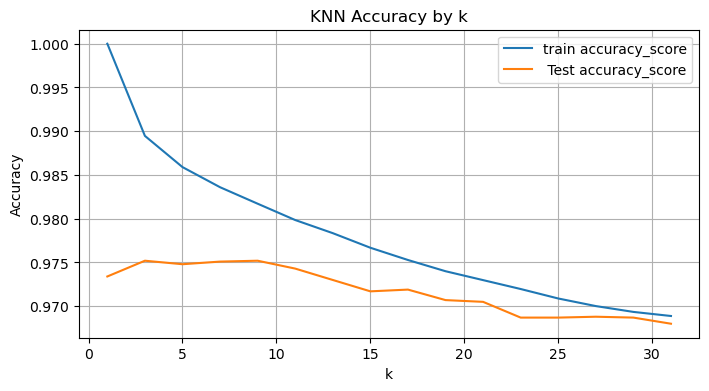

In [23]:
## k-곡선 시각화
plt.figure(figsize=(8,4))
plt.plot(scoreDF["k"], scoreDF["train"], label="train accuracy_score")
plt.plot(scoreDF["k"], scoreDF["test"], label=" Test accuracy_score")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy by k")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
## 최적 k 최종 학습 및 평가
knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
knn.fit(X_train_f, y_train)
y_pred = knn.predict(X_test_f)

print("Test 정확도 : ", accuracy_score(y_test, y_pred))
print("\n[클래스별 성능]\n", classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

Test 정확도 :  0.968

[클래스별 성능]
               precision    recall  f1-score   support

           0     0.9700    0.9908    0.9803       980
           1     0.9528    0.9956    0.9737      1135
           2     0.9850    0.9574    0.9710      1032
           3     0.9693    0.9703    0.9698      1010
           4     0.9781    0.9562    0.9670       982
           5     0.9773    0.9664    0.9718       892
           6     0.9652    0.9854    0.9752       958
           7     0.9655    0.9523    0.9589      1028
           8     0.9788    0.9497    0.9640       974
           9     0.9431    0.9534    0.9483      1009

    accuracy                         0.9680     10000
   macro avg     0.9685    0.9677    0.9680     10000
weighted avg     0.9682    0.9680    0.9680     10000



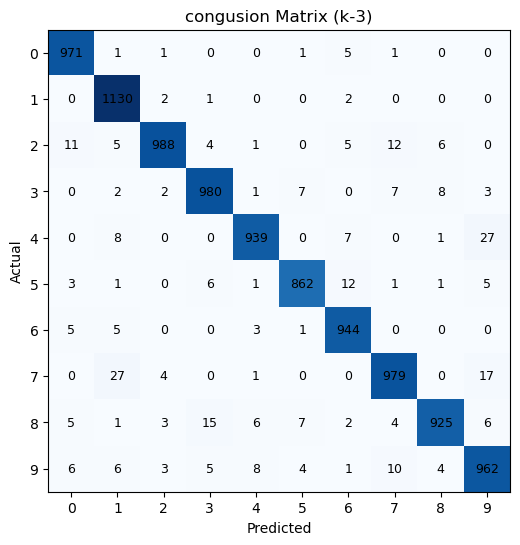

In [25]:
## 혼동행렬 + 클래스별 정확도 시각화
## 혼동행렬
plt.figure(figsize=(8,6))
im = plt.imshow(cm, cmap="Blues")
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"congusion Matrix (k-{best_k})")

for i in range(10) :
    for j in range(10) :
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=9)
plt.show()

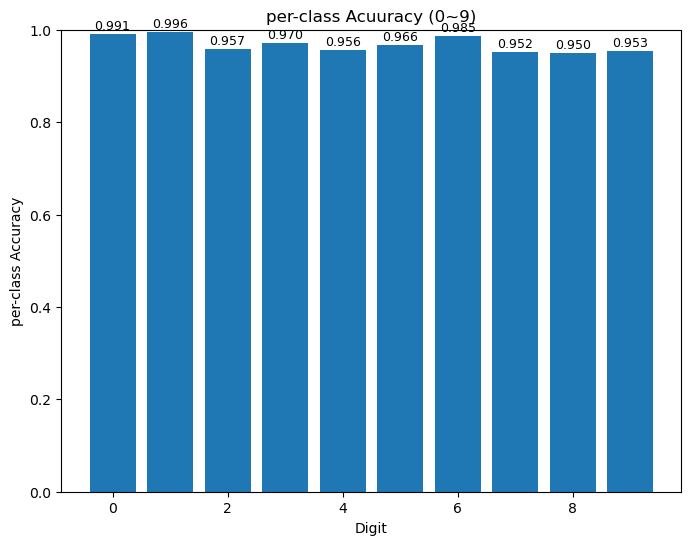

In [26]:
## 클래스별 정확도 시각화
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 6))
plt.bar(range(10), per_class_acc)
plt.ylim(0,1)

for i, v in enumerate(per_class_acc) :
    plt.text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.xlabel("Digit")
plt.ylabel("per-class Accuracy")
plt.title("per-class Acuuracy (0~9)")
plt.show()

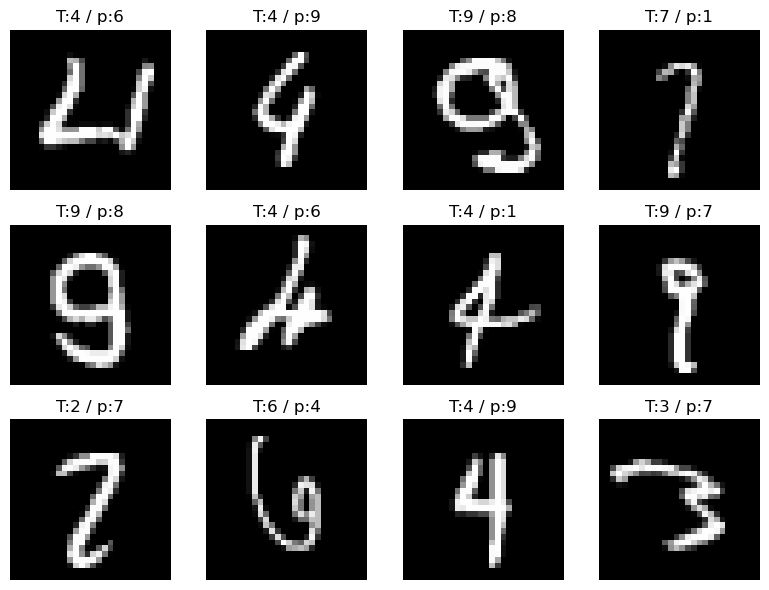

In [27]:
## 오분류 시각화
mis_idx = np.where(y_pred != y_test)[0]
n_show = min(12, len(mis_idx))

plt.figure(figsize=(8,6))
for i, ix in enumerate(mis_idx[:n_show]):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_test[ix].reshape(28, 28), cmap="gray")
    plt.title(f"T:{y_test[ix]} / p:{y_pred[ix]}")
    plt.axis("off")

plt.tight_layout() 
plt.show()

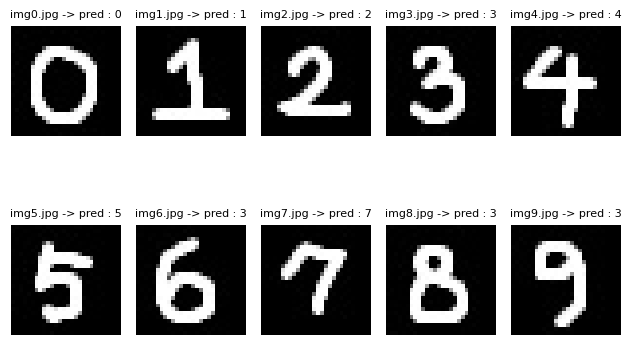

In [28]:
## 내 손글씨 이미지 예측
import cv2
import glob
import os

## 이미지 파일 불러오기
IMG_DIR = '../Data/Image/number/'
IMG_FILES = [f"img{i}.jpg" for i in range(10)] # img0.jpg ~ img9.jpg

def preprocess_img(path, use_pca=USE_PCA) :
    # 이미지별 MNIST 입력 형태 전처리
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28,28), interpolation=cv2.INTER_AREA)
    if img.mean() > 127 : # 배경이 밝으면 반전
        img = 255 - img
    vec = (img.astype("float") / 255.0).reshape(1, -1)
    if use_pca : 
        vec = pca.transform(vec)

    return vec, img

## 예측
for i, fname in enumerate(IMG_FILES) :
    path = os.path.join(IMG_DIR, fname)
    x_new, img28 = preprocess_img(path)
    pred = knn.predict(x_new)[0]

    # 결과 출력
    plt.subplot(2, 5, i+1)  # 2행 5열
    plt.imshow(img28, cmap='gray')
    plt.title(f'{fname} -> pred : {pred}', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
## 거리/가중치/이웃 튜닝(재학습)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

## 파라미터 후보
param_grid = {
    "n_neighbors" : [3, 5, 7, 9, 11, 13, 15],
    "weights"     : ["uniform", "distance"],
    "metric"      : ["euclidean", "manhattan"]}

## GridSearchCV 객체 생성
grid =GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid, cv=3, scoring="accuracy", n_jobs=-1)

## 학습
grid.fit(X_train_f, y_train)

## 최적 모델
best_knn = grid.best_estimator_
print("Best params:", grid.best_params_)
print("CV best score:", round(grid.best_score_, 4))

## 교차검증 테스트 평가
y_pred = best_knn.predict(X_test_f)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
CV best score: 0.974
Test Accuracy: 0.976
              precision    recall  f1-score   support

           0     0.9779    0.9949    0.9863       980
           1     0.9826    0.9956    0.9891      1135
           2     0.9824    0.9758    0.9791      1032
           3     0.9682    0.9634    0.9658      1010
           4     0.9796    0.9776    0.9786       982
           5     0.9751    0.9664    0.9707       892
           6     0.9793    0.9854    0.9823       958
           7     0.9708    0.9708    0.9708      1028
           8     0.9760    0.9600    0.9679       974
           9     0.9673    0.9673    0.9673      1009

    accuracy                         0.9760     10000
   macro avg     0.9759    0.9757    0.9758     10000
weighted avg     0.9760    0.9760    0.9760     10000



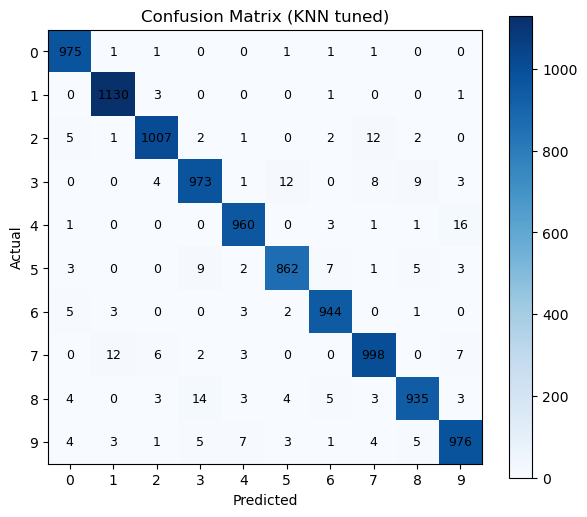

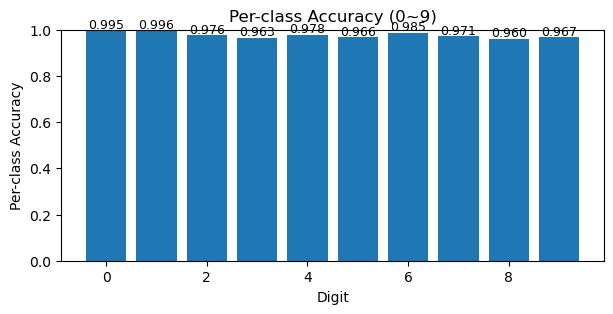

In [30]:
## 재학습 모델 혼동행렬 및 클래스별 정확도
cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))

# 혼동행렬
plt.figure(figsize=(7,6))
im = plt.imshow(cm, cmap="Blues")
plt.colorbar(im)
plt.xticks(np.arange(10)); plt.yticks(np.arange(10))
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix (KNN tuned)")
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=9)
plt.show()

# 클래스별 정확도
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(7,3))
plt.bar(range(10), per_class_acc)
plt.ylim(0,1)
for i, v in enumerate(per_class_acc):
    plt.text(i, v+0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.xlabel("Digit"); plt.ylabel("Per-class Accuracy")
plt.title("Per-class Accuracy (0~9)")
plt.show()


[6] Logistic Regression 모델 <hr>

In [31]:
## 모듈 로딩
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
## 데이터 경로
DATA_DIR   = '../Data/MNIST/'
TRAIN_FILE = '../Data/MNIST/train.csv'
TEST_FILE  = '../Data/MNIST/t10k.csv'
USE_PCA    = True    # 주성분 분석
N_COMP     = 50      # PCA 차원 수

In [33]:
## 데이터 로딩
## train 
trainDF = pd.read_csv(TRAIN_FILE, header=None, dtype='int', low_memory=False)
X_train = trainDF.iloc[:, 1:].to_numpy()
y_train = trainDF.iloc[:, 0 ].to_numpy()

## test
testDF  = pd.read_csv(TEST_FILE, header=None, dtype='int', low_memory=False)
X_test  = testDF.iloc[:, 1:].to_numpy()
y_test  = testDF.iloc[:, 0 ].to_numpy()

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (60000, 784) X_test: (10000, 784)


In [34]:
## 데이터 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## 스케일링/차원축소
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("pca", PCA(n_components=50, random_state=42)),
    ("clf", LogisticRegression(max_iter=5000, n_jobs=-1))
])

In [35]:
# ## GridSearchCV 튜닝(하이퍼파라미터 탐색)
# from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold
# from sklearn.linear_model import LogisticRegression

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = [
#     {'clf__solver': ['lbfgs', 'newton-cg', 'sag'],
#      'clf__penalty': ['l2'],
#      'clf__C': [0.01, 0.1, 1, 5, 10],
#      'clf__multi_class': ['multinomial']},

#     {'clf__solver': ['liblinear'],
#      'clf__penalty': ['l1', 'l2'],
#      'clf__C': [0.01, 0.1, 1, 5, 10],
#      'clf__multi_class': ['ovr']},

#     {'clf__solver': ['saga'],
#      'clf__penalty': ['l1', 'l2'],
#      'clf__C': [0.01, 0.1, 1, 5, 10],
#      'clf__multi_class': ['multinomial']},
# ]

# grid = GridSearchCV(
#     estimator=pipe,
#     param_grid=param_grid,
#     scoring='accuracy',
#     cv=cv,
#     n_jobs=-1,
#     verbose=1,
# )

# grid.fit(X_train, y_train)

# print('최적 파라미터 :', grid.best_params_)
# print('CV 최적 평균 정확도 : ', round(grid.best_score_, 4))

# ## 테스트 평가
# from sklearn.metrics import accuracy_score, classification_report
# y_pred = grid.predict(X_test)
# print('Test acc:', round(accuracy_score(y_test, y_pred)), 4)
# print(classification_report(y_test, y_pred, digits=4))

In [36]:
## GridSearchCV 튜닝(하이퍼파라미터 탐색)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {'clf__solver': ['lbfgs'],
     'clf__penalty': ['l2'],
     'clf__C': [1],
     'clf__multi_class': ['multinomial']},
]

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print('최적 파라미터 :', grid.best_params_)
print('CV 최적 평균 정확도 : ', round(grid.best_score_, 4))

## 테스트 평가
from sklearn.metrics import accuracy_score, classification_report
y_pred = grid.predict(X_test)
print('Test acc:', round(accuracy_score(y_test, y_pred)), 4)
print(classification_report(y_test, y_pred, digits=4))

Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\KDT-57-\anaconda3\envs\CV_ML\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


최적 파라미터 : {'clf__C': 1, 'clf__multi_class': 'multinomial', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
CV 최적 평균 정확도 :  0.9026
Test acc: 1 4
              precision    recall  f1-score   support

           0     0.9295    0.9694    0.9491       980
           1     0.9584    0.9736    0.9659      1135
           2     0.9041    0.8682    0.8858      1032
           3     0.8813    0.8891    0.8852      1010
           4     0.8976    0.9196    0.9085       982
           5     0.8654    0.8430    0.8541       892
           6     0.9270    0.9405    0.9337       958
           7     0.9162    0.9037    0.9099      1028
           8     0.8643    0.8501    0.8571       974
           9     0.8886    0.8771    0.8828      1009

    accuracy                         0.9047     10000
   macro avg     0.9032    0.9034    0.9032     10000
weighted avg     0.9043    0.9047    0.9044     10000



In [37]:
# 최적 모델로 교체
best_clf = grid.best_estimator_

## 최적 모델 성능 확인
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

## 예측 확률
y_pred_best  = best_clf.predict(X_test)
y_proba_best = best_clf.predict_proba(X_test)

## 성능 지표
print(f'[BEST] Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'[BEST] precision : {precision_score(y_test, y_pred_best, average="macro"):.4f}')
print(f'[BEST] Recall    : {recall_score(y_test, y_pred_best, average="macro"):.4f}')
print(f'[Best] F1-score  : {f1_score(y_test, y_pred_best, average="macro"):.4f}')

## 멀티클래스 ROC-AUC (ovr)
print(f'[Best] ROC-AUC   : {roc_auc_score(y_test, y_proba_best, average="macro", multi_class="ovr"):.4f}')

print('\n[Classification Report]\n',
      classification_report(y_test, y_pred_best, digits=4))

## 혼동행렬 예측값
print('[Confusion Matrix]\n', confusion_matrix(y_test, y_pred))

[BEST] Accuracy  : 0.9047
[BEST] precision : 0.9032
[BEST] Recall    : 0.9034
[Best] F1-score  : 0.9032
[Best] ROC-AUC   : 0.9917

[Classification Report]
               precision    recall  f1-score   support

           0     0.9295    0.9694    0.9491       980
           1     0.9584    0.9736    0.9659      1135
           2     0.9041    0.8682    0.8858      1032
           3     0.8813    0.8891    0.8852      1010
           4     0.8976    0.9196    0.9085       982
           5     0.8654    0.8430    0.8541       892
           6     0.9270    0.9405    0.9337       958
           7     0.9162    0.9037    0.9099      1028
           8     0.8643    0.8501    0.8571       974
           9     0.8886    0.8771    0.8828      1009

    accuracy                         0.9047     10000
   macro avg     0.9032    0.9034    0.9032     10000
weighted avg     0.9043    0.9047    0.9044     10000

[Confusion Matrix]
 [[ 950    0    2    2    0   14    6    2    4    0]
 [   0 1105 

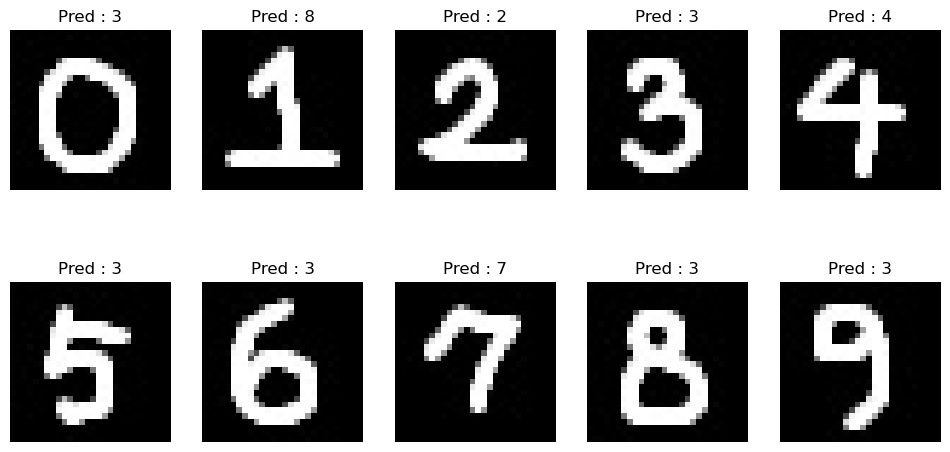

예측 결과: [np.int64(3), np.int64(8), np.int64(2), np.int64(3), np.int64(4), np.int64(3), np.int64(3), np.int64(7), np.int64(3), np.int64(3)]


In [38]:
## 내 손글씨 예측 코드
## 이미지 파일 로딩
IMG_DIR   = '../Data/Image/number/'
IMG_FILES = [f'{IMG_DIR}img{i}.jpg' for i in range(10)]

## 예측값 저장
preds = []

plt.figure(figsize=(12,6))

for idx, file in enumerate(IMG_FILES) :
    img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

    # MNIST 크기로 맞춤
    img_resized = cv2.resize(img, (28, 28))

    # 색상 반전
    img_resized = 255 - img_resized

    # 1차원 벡터로 변환
    img_flat = img_resized.reshape(1, -1)
    
    # 예측
    pred = best_clf.predict(img_flat)[0]
    preds.append(pred)

    # 시각화
    plt.subplot(2, 5, idx+1)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f'Pred : {pred}')
    plt.axis("off")

plt.show()

print("예측 결과:", preds)

In [39]:
import cv2
import numpy as np

def center_pad_28(img_gray):
    """입력: 0~255 GRAY uint8 (아무 크기)
       출력: (28x28 uint8, 시각화용 28x28) - 배경 검정(0), 글자 흰(255)"""
    im = img_gray.copy()
    # 배경 밝으면 반전해서 MNIST와 같게(배경=검정, 글자=흰)
    if im.mean() > 127:
        im = 255 - im

    # 가우시안 살짝 -> 이진화 안정화
    im = cv2.GaussianBlur(im, (3,3), 0)

    # Otsu 이진화 (글자=255)
    _, bw = cv2.threshold(im, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)

    # 글자 영역 bbox
    ys, xs = np.where(bw > 0)
    if len(xs) == 0 or len(ys) == 0:
        # 글자 못 찾으면 그냥 중앙 28x28로 축소
        small = cv2.resize(im, (20,20), interpolation=cv2.INTER_AREA)
        canvas = np.zeros((28,28), np.uint8)
        y0 = (28-small.shape[0])//2; x0 = (28-small.shape[1])//2
        canvas[y0:y0+small.shape[0], x0:x0+small.shape[1]] = small
        return canvas, canvas

    crop = im[ys.min():ys.max()+1, xs.min():xs.max()+1]

    # 긴 변을 20으로 리사이즈 (비율 유지)
    h, w = crop.shape
    scale = 20.0 / max(h, w)
    nh, nw = max(1, int(h*scale)), max(1, int(w*scale))
    small = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_AREA)

    # 28x28 중앙 패딩
    canvas = np.zeros((28,28), np.uint8)
    y0 = (28 - nh)//2
    x0 = (28 - nw)//2
    canvas[y0:y0+nh, x0:x0+nw] = small

    # 무게중심으로 미세 중앙정렬 (선택)
    M = cv2.moments(canvas)
    if M["m00"] != 0:
        cx = M["m10"]/M["m00"]; cy = M["m01"]/M["m00"]
        shiftx = int(round(14 - cx))
        shifty = int(round(14 - cy))
        T = np.float32([[1,0,shiftx],[0,1,shifty]])
        canvas = cv2.warpAffine(canvas, T, (28,28), borderValue=0)

    # 최종: 배경 0, 글자 255
    # (파이프라인 내부 스케일러가 처리하므로 0~255 uint8로 두면 OK)
    return canvas, canvas


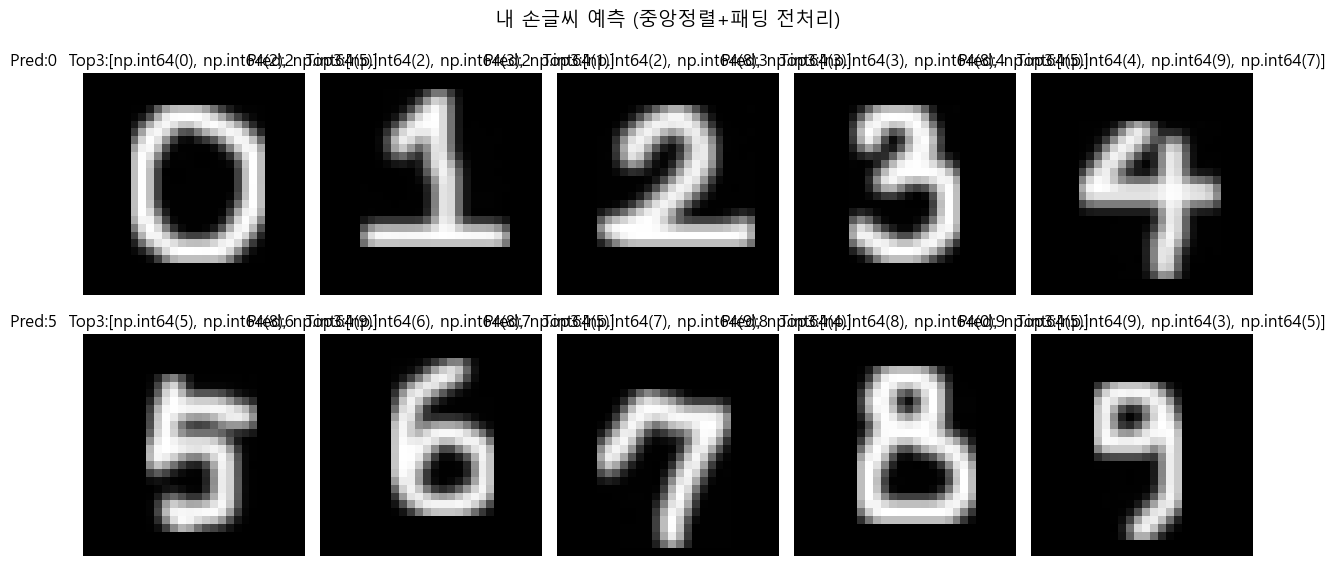

예측 결과: [0, 2, 2, 3, 4, 5, 6, 7, 8, 9]


In [40]:
import os, matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
rcParams['axes.unicode_minus'] = False     # 마이너스 기호 깨짐 방지

IMG_DIR   = '../Data/Image/number/'
IMG_FILES = [f'{IMG_DIR}img{i}.jpg' for i in range(10)]

preds = []
plt.figure(figsize=(12,6))

for i, path in enumerate(IMG_FILES):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"이미지를 불러올 수 없음: {path}")
        continue

    img28, show = center_pad_28(img)      # 👈 핵심 전처리
    x_flat = img28.reshape(1, -1)          # (1, 784)
    pred = best_clf.predict(x_flat)[0]
    proba = best_clf.predict_proba(x_flat)[0]
    top3 = np.argsort(proba)[-3:][::-1]
    preds.append(int(pred))

    plt.subplot(2,5,i+1)
    plt.imshow(show, cmap='gray')
    plt.title(f'Pred:{pred}  Top3:{list(top3)}')
    plt.axis('off')

plt.suptitle("내 손글씨 예측 (중앙정렬+패딩 전처리)", fontsize=14)
plt.tight_layout(); plt.show()

print("예측 결과:", preds)
